# Lecture 03 — Logistic Regression & Classification

**Learning objectives**

- Formulate binary classification probabilistically and motivate the sigmoid link.
- Derive the cross-entropy loss as the negative Bernoulli log-likelihood, and derive its gradient and Hessian.
- Prove that the logistic loss is convex and understand what that buys us.
- Implement L2-regularized logistic regression with gradient descent from scratch and match scikit-learn.
- Generalize to $K$ classes with softmax regression; derive and implement its gradient.
- Evaluate classifiers properly: confusion matrix, accuracy, precision, recall, $F_1$, ROC/AUC (from scratch), precision–recall curves.
- Choose decision thresholds, handle class imbalance, and assess probability calibration.

**Prerequisites**: `01_*.ipynb` (ML foundations, NumPy), `02_*.ipynb` (linear regression, gradient descent, regularization). Basic probability (Bernoulli, likelihood) and multivariable calculus.

**Contents**

1. The classification setup
2. The sigmoid and the logistic model
3. Maximum likelihood: from Bernoulli to cross-entropy
4. Gradient, Hessian and convexity
5. From-scratch gradient descent with L2 regularization
6. Decision boundaries
7. Comparison with scikit-learn on breast cancer data
8. Softmax regression for multiclass problems
9. Classification metrics
10. ROC curves and AUC (from scratch)
11. Precision–recall curves and threshold selection
12. Class imbalance
13. Probability calibration
14. Pitfalls & practical tips
15. Exercises
16. Summary & further reading

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.datasets import load_breast_cancer, load_digits, make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=4, suppress=True)

## 1. The classification setup

We observe pairs $(\mathbf{x}_i, y_i)_{i=1}^n$ with $\mathbf{x}_i \in \mathbb{R}^d$ and a **discrete** label $y_i \in \{0, 1\}$ (binary) or $y_i \in \{1,\dots,K\}$ (multiclass). The goal is a classifier $h: \mathbb{R}^d \to \{0,1\}$ with small **expected 0–1 risk**

$$
R(h) = \mathbb{E}_{(\mathbf{x},y)}\big[\mathbb{1}\{h(\mathbf{x}) \neq y\}\big] = \Pr\big(h(\mathbf{x}) \neq y\big).
$$

The risk is minimized by the **Bayes classifier** $h^*(\mathbf{x}) = \mathbb{1}\{\Pr(y=1\mid\mathbf{x}) > 1/2\}$. So a natural strategy is to **model the conditional probability** $p(\mathbf{x}) = \Pr(y=1 \mid \mathbf{x})$ and threshold it. This is the *discriminative* approach (we model $p(y\mid\mathbf{x})$ directly, not $p(\mathbf{x}\mid y)$; see Lecture 05 for the generative alternative).

**Why not just use linear regression on $\{0,1\}$ targets?**

- Predictions $\mathbf{w}^\top\mathbf{x}$ are unbounded, so they cannot be probabilities.
- Squared error heavily penalizes points that are *correctly* classified with large margin, so outliers far on the correct side drag the boundary.
- The 0–1 loss itself is non-convex and has zero gradient almost everywhere, so we need a smooth, convex *surrogate*.

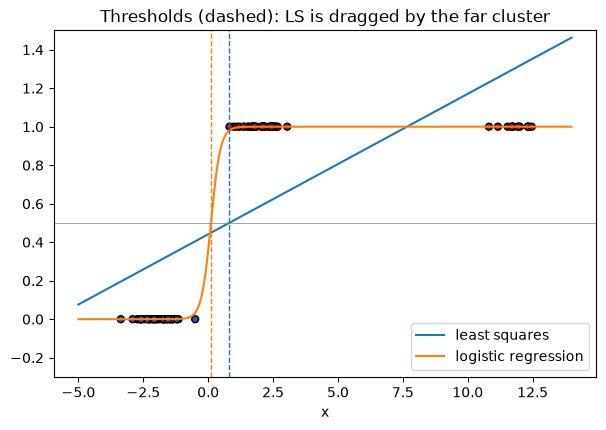

In [2]:
# Illustration: least squares vs logistic regression on 1-D data with a far-away (but correct) cluster
x = np.r_[rng.normal(-2, 0.7, 40), rng.normal(2, 0.7, 40), rng.normal(12, 0.7, 15)]
y = np.r_[np.zeros(40), np.ones(40), np.ones(15)]
X1 = np.c_[np.ones_like(x), x]
w_ls = np.linalg.lstsq(X1, y, rcond=None)[0]                 # least-squares fit
clf = LogisticRegression(C=100).fit(x[:, None], y)

grid = np.linspace(-5, 14, 400)
plt.scatter(x, y, c=y, cmap="coolwarm", edgecolor="k", s=25)
plt.plot(grid, w_ls[0] + w_ls[1] * grid, label="least squares")
plt.plot(grid, clf.predict_proba(grid[:, None])[:, 1], label="logistic regression")
plt.axvline((0.5 - w_ls[0]) / w_ls[1], ls="--", c="C0", lw=1)
plt.axvline(-clf.intercept_[0] / clf.coef_[0, 0], ls="--", c="C1", lw=1)
plt.axhline(0.5, c="gray", lw=0.5)
plt.ylim(-0.3, 1.5); plt.xlabel("x"); plt.legend(); plt.title("Thresholds (dashed): LS is dragged by the far cluster")
plt.show()

## 2. The sigmoid and the logistic model

We want a map from a real-valued score $z = \mathbf{w}^\top \mathbf{x} + b$ to $(0,1)$. The **logistic sigmoid**

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

is the canonical choice. The logistic regression model is

$$
p(\mathbf{x}) = \Pr(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x} + b).
$$

**Properties** (all easy to verify):

- $\sigma(-z) = 1 - \sigma(z)$ (symmetry).
- $\sigma'(z) = \sigma(z)\,(1-\sigma(z))$ — this makes the gradient beautifully simple.
- Inverse: $\sigma^{-1}(p) = \log\frac{p}{1-p}$, the **log-odds** or **logit**.

Hence the model says the **log-odds are linear in $\mathbf{x}$**:

$$
\log \frac{\Pr(y=1\mid\mathbf{x})}{\Pr(y=0\mid\mathbf{x})} = \mathbf{w}^\top\mathbf{x} + b.
$$

Interpretation: increasing feature $x_j$ by one unit multiplies the odds by $e^{w_j}$. The **decision boundary** $\{p(\mathbf{x}) = 1/2\} = \{\mathbf{w}^\top\mathbf{x}+b = 0\}$ is a hyperplane: logistic regression is a *linear* classifier.

**Where does the sigmoid come from?** If the class-conditionals are Gaussians with shared covariance (or any exponential family with shared dispersion), Bayes' rule gives exactly a sigmoid of a linear function for the posterior (Bishop PRML §4.2). It is also the canonical link of the Bernoulli GLM.

**Numerical note**: computing `1/(1+np.exp(-z))` overflows for very negative $z$. A stable implementation branches on the sign of $z$.

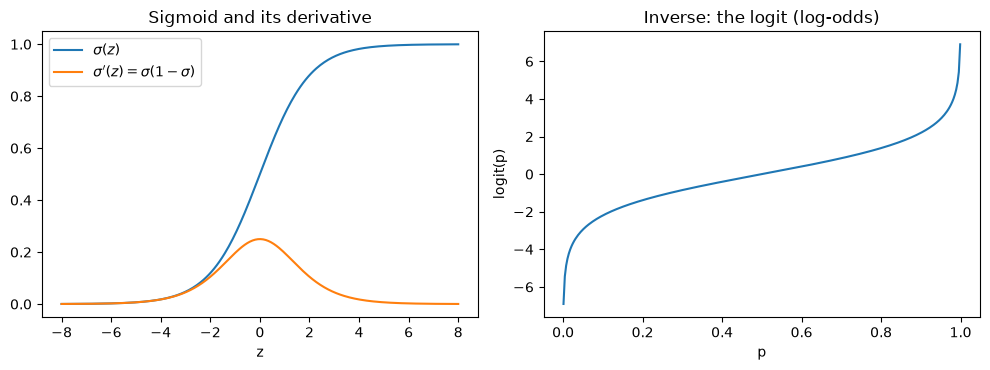

symmetry error: 1.4051260155412137e-16
derivative error: 1.4199761678990175e-10
extreme inputs: [0.  0.5 1. ]


In [3]:
def sigmoid(z):
    # Numerically stable sigmoid: never exponentiates a large positive number.
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

z = np.linspace(-8, 8, 300)
s = sigmoid(z)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(z, s, label=r"$\sigma(z)$")
ax[0].plot(z, s * (1 - s), label=r"$\sigma'(z)=\sigma(1-\sigma)$")
ax[0].legend(); ax[0].set_xlabel("z"); ax[0].set_title("Sigmoid and its derivative")
p = np.linspace(0.001, 0.999, 300)
ax[1].plot(p, np.log(p / (1 - p))); ax[1].set_xlabel("p"); ax[1].set_ylabel("logit(p)")
ax[1].set_title("Inverse: the logit (log-odds)")
plt.tight_layout(); plt.show()

# Sanity checks: symmetry, derivative via finite differences, stability
eps = 1e-6
print("symmetry error:", np.max(np.abs(sigmoid(-z) - (1 - sigmoid(z)))))
print("derivative error:", np.max(np.abs((sigmoid(z + eps) - sigmoid(z - eps)) / (2 * eps) - s * (1 - s))))
print("extreme inputs:", sigmoid(np.array([-1000.0, 0.0, 1000.0])))

## 3. Maximum likelihood: from Bernoulli to cross-entropy

Absorb the bias into $\mathbf{w}$ by appending a constant feature $1$ to $\mathbf{x}$ (we will separate them again when regularizing). Let $p_i = \sigma(\mathbf{w}^\top\mathbf{x}_i)$. Each label is a Bernoulli draw:

$$
\Pr(y_i \mid \mathbf{x}_i, \mathbf{w}) = p_i^{\,y_i}\,(1-p_i)^{1-y_i}.
$$

Assuming i.i.d. samples, the likelihood and log-likelihood are

$$
L(\mathbf{w}) = \prod_{i=1}^n p_i^{\,y_i}(1-p_i)^{1-y_i},
\qquad
\ell(\mathbf{w}) = \sum_{i=1}^n \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big].
$$

Maximizing $\ell$ is equivalent to minimizing the **average negative log-likelihood**, a.k.a. **binary cross-entropy (log loss)**:

$$
J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^n \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big].
$$

**Information-theoretic view.** For each $i$, the term is the cross-entropy $H(q_i, p_i) = -\sum_{c} q_i(c)\log p_i(c)$ between the empirical one-hot distribution $q_i$ and the model's distribution — hence the name. Minimizing cross-entropy = minimizing $\mathrm{KL}(q\,\|\,p)$ up to a constant.

**Margin view.** With labels $\tilde y_i = 2y_i - 1 \in \{-1,+1\}$ and score $z_i = \mathbf{w}^\top\mathbf{x}_i$, using $1-\sigma(z) = \sigma(-z)$ the per-sample loss becomes

$$
\ell_{\log}(\tilde y_i z_i) = \log\big(1 + e^{-\tilde y_i z_i}\big),
$$

a smooth, convex upper bound (after rescaling by $1/\log 2$) on the 0–1 loss $\mathbb{1}\{\tilde y z \le 0\}$. Compare with the hinge loss of SVMs, $\max(0, 1-\tilde y z)$.

**No closed form.** Setting the gradient to zero gives nonlinear equations in $\mathbf{w}$; we solve them iteratively (gradient descent, Newton/IRLS, L-BFGS).

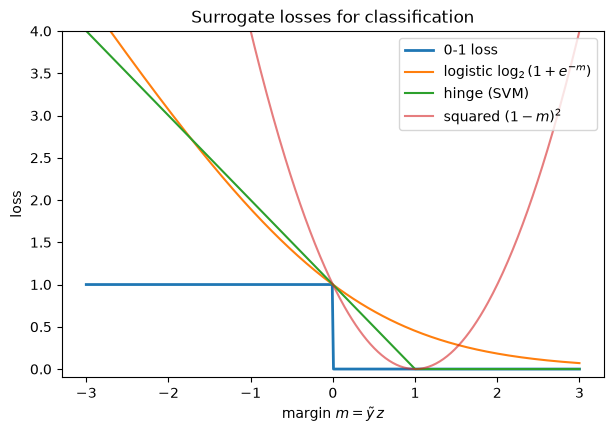

In [4]:
m = np.linspace(-3, 3, 400)   # margin  y~ * z
plt.plot(m, (m <= 0).astype(float), label="0-1 loss", lw=2)
plt.plot(m, np.log1p(np.exp(-m)) / np.log(2), label=r"logistic $\log_2(1+e^{-m})$")
plt.plot(m, np.maximum(0, 1 - m), label="hinge (SVM)")
plt.plot(m, (1 - m) ** 2, label="squared $(1-m)^2$", alpha=0.6)
plt.ylim(-0.1, 4); plt.xlabel(r"margin $m=\tilde{y}\,z$"); plt.ylabel("loss")
plt.title("Surrogate losses for classification"); plt.legend(); plt.show()

## 4. Gradient, Hessian and convexity

**Gradient.** Using $\partial p_i / \partial z_i = p_i(1-p_i)$ and $\partial z_i/\partial \mathbf{w} = \mathbf{x}_i$, the chain rule gives, for one sample,

$$
\frac{\partial}{\partial \mathbf{w}}\Big[-y_i\log p_i - (1-y_i)\log(1-p_i)\Big]
= \Big(-\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i}\Big)\,p_i(1-p_i)\,\mathbf{x}_i
= (p_i - y_i)\,\mathbf{x}_i .
$$

Therefore, in matrix form with design matrix $X \in \mathbb{R}^{n\times d}$ and $\mathbf{p} = \sigma(X\mathbf{w})$:

$$
\boxed{\nabla J(\mathbf{w}) = \frac{1}{n} X^\top(\mathbf{p} - \mathbf{y})}
$$

This is formally identical to the least-squares gradient $\frac1n X^\top(X\mathbf{w}-\mathbf{y})$ — "prediction minus target, times input" — a hallmark of GLMs with canonical links.

**Hessian.** Differentiating once more,

$$
\nabla^2 J(\mathbf{w}) = \frac{1}{n}\sum_i p_i(1-p_i)\,\mathbf{x}_i\mathbf{x}_i^\top = \frac{1}{n} X^\top S X,
\qquad S = \mathrm{diag}\big(p_i(1-p_i)\big).
$$

**Convexity.** For any $\mathbf{v}$: $\mathbf{v}^\top X^\top S X \mathbf{v} = \sum_i p_i(1-p_i)(\mathbf{x}_i^\top \mathbf{v})^2 \ge 0$, since $0 < p_i < 1$. The Hessian is positive semidefinite everywhere, so $J$ is **convex**: every local minimum is global and gradient descent with a suitable step size converges to it. Adding an L2 penalty $\frac{\lambda}{2}\|\mathbf{w}\|^2$ adds $\lambda I$ to the Hessian, making $J$ **strictly (indeed strongly) convex** with a unique minimizer.

**Step size.** Since $p(1-p) \le 1/4$, $\nabla^2 J \preceq \frac{1}{4n} X^\top X$, so $J$ is $L$-smooth with $L = \lambda_{\max}(X^\top X)/(4n) + \lambda$. A step size $\eta = 1/L$ guarantees monotone decrease.

**Separable data caveat.** If the classes are linearly separable, scaling $\mathbf{w}\to c\,\mathbf{w}$ with $c\to\infty$ drives the unregularized loss to $0$: the MLE **does not exist** (weights diverge). Regularization fixes this.

**Newton's method / IRLS.** The update $\mathbf{w} \leftarrow \mathbf{w} - (X^\top S X)^{-1}X^\top(\mathbf{p}-\mathbf{y})$ can be rewritten as a weighted least-squares problem that is re-solved each iteration (Iteratively Reweighted Least Squares). It converges quadratically but costs $O(nd^2 + d^3)$ per step.

## 5. From-scratch gradient descent with L2 regularization

We minimize

$$
J_\lambda(\mathbf{w}, b) = -\frac{1}{n}\sum_{i}\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big] + \frac{\lambda}{2}\|\mathbf{w}\|_2^2,
\qquad p_i = \sigma(\mathbf{w}^\top\mathbf{x}_i + b),
$$

with gradients

$$
\nabla_{\mathbf{w}} J_\lambda = \frac1n X^\top(\mathbf{p}-\mathbf{y}) + \lambda\mathbf{w},
\qquad
\frac{\partial J_\lambda}{\partial b} = \frac1n \mathbf{1}^\top(\mathbf{p}-\mathbf{y}).
$$

The bias is conventionally **not** penalized (penalizing it would make the model depend on the label coding / class balance). For the loss we use the numerically stable identity $-\log\sigma(z) = \log(1+e^{-z}) = \texttt{logaddexp}(0, -z)$.

**Link to scikit-learn.** `LogisticRegression(C=C)` minimizes $\sum_i \ell_i + \frac{1}{2C}\|\mathbf{w}\|^2$. Dividing by $n$: this equals our objective with $\lambda = 1/(nC)$.

In [5]:
class LogisticRegressionGD:
    # Binary logistic regression with L2 penalty, trained by full-batch gradient descent.

    def __init__(self, lam=0.0, lr=None, n_iter=2000, tol=1e-10):
        self.lam, self.lr, self.n_iter, self.tol = lam, lr, n_iter, tol

    @staticmethod
    def _loss(z, y):
        # mean cross-entropy computed from logits z in a stable way:
        # -[y log s(z) + (1-y) log(1-s(z))] = y*logaddexp(0,-z) + (1-y)*logaddexp(0,z)
        return np.mean(y * np.logaddexp(0, -z) + (1 - y) * np.logaddexp(0, z))

    def objective(self, X, y):
        z = X @ self.w + self.b
        return self._loss(z, y) + 0.5 * self.lam * self.w @ self.w

    def fit(self, X, y):
        n, d = X.shape
        self.w, self.b = np.zeros(d), 0.0
        if self.lr is None:
            # 1/L with L = lambda_max([X 1]^T [X 1]) / (4n) + lam  (smoothness constant incl. bias)
            X1 = np.c_[X, np.ones(n)]
            L = np.linalg.eigvalsh(X1.T @ X1 / n).max() / 4 + self.lam
            self.lr = 1.0 / L
        self.history = [self.objective(X, y)]
        for _ in range(self.n_iter):
            p = sigmoid(X @ self.w + self.b)
            r = p - y                                  # residuals "prediction - target"
            grad_w = X.T @ r / n + self.lam * self.w
            grad_b = r.mean()
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            self.history.append(self.objective(X, y))
            if abs(self.history[-2] - self.history[-1]) < self.tol:
                break
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

**Gradient check.** Before trusting an optimizer, verify the analytic gradient against central finite differences on random parameters.

In [6]:
Xc, yc = make_classification(n_samples=50, n_features=4, n_informative=3, n_redundant=0, random_state=0)
m_ = LogisticRegressionGD(lam=0.3)
m_.w, m_.b = rng.normal(size=4), 0.2

p = sigmoid(Xc @ m_.w + m_.b)
g_analytic = Xc.T @ (p - yc) / len(yc) + m_.lam * m_.w

g_numeric = np.zeros(4)
eps = 1e-6
for j in range(4):
    e = np.zeros(4); e[j] = eps
    m_.w += e;      f_plus = m_.objective(Xc, yc)
    m_.w -= 2 * e;  f_minus = m_.objective(Xc, yc)
    m_.w += e
    g_numeric[j] = (f_plus - f_minus) / (2 * eps)
print("analytic:", g_analytic)
print("numeric: ", g_numeric)
print("max abs diff:", np.abs(g_analytic - g_numeric).max())

analytic: [-0.626  -0.8601 -0.4044  0.0813]
numeric:  [-0.626  -0.8601 -0.4044  0.0813]
max abs diff: 5.111429057791383e-10


## 6. Decision boundaries

We fit the model on a 2-D synthetic problem. Because the boundary $\mathbf{w}^\top\mathbf{x}+b=0$ is a line, it cannot separate the "two moons"; adding polynomial features (a fixed nonlinear feature map $\phi(\mathbf{x})$) yields a nonlinear boundary while the optimization problem stays convex in $\mathbf{w}$. Stronger regularization smooths the boundary.

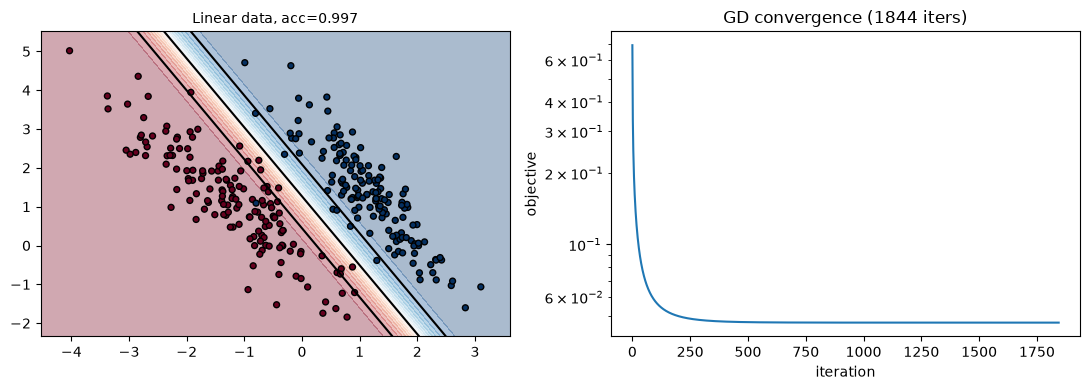

w = [-4.7453 -2.6737]  b = 3.3876


In [7]:
def plot_boundary(ax, predict_proba, X, y, title, levels=(0.5,)):
    x0, x1 = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250))
    P = predict_proba(np.c_[x0.ravel(), x1.ravel()]).reshape(x0.shape)
    ax.contourf(x0, x1, P, levels=20, cmap="RdBu_r", alpha=0.35)
    ax.contour(x0, x1, P, levels=list(levels), colors="k", linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=18)
    ax.set_title(title, fontsize=10)

Xb, yb = make_classification(n_samples=300, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, class_sep=1.2, random_state=3)
lin = LogisticRegressionGD(lam=1e-3).fit(Xb, yb)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(ax[0], lin.predict_proba, Xb, yb, f"Linear data, acc={np.mean(lin.predict(Xb) == yb):.3f}",
              levels=(0.1, 0.5, 0.9))
ax[1].plot(lin.history); ax[1].set_yscale("log"); ax[1].set_xlabel("iteration")
ax[1].set_ylabel("objective"); ax[1].set_title(f"GD convergence ({len(lin.history)-1} iters)")
plt.tight_layout(); plt.show()
print("w =", lin.w, " b =", round(lin.b, 4))

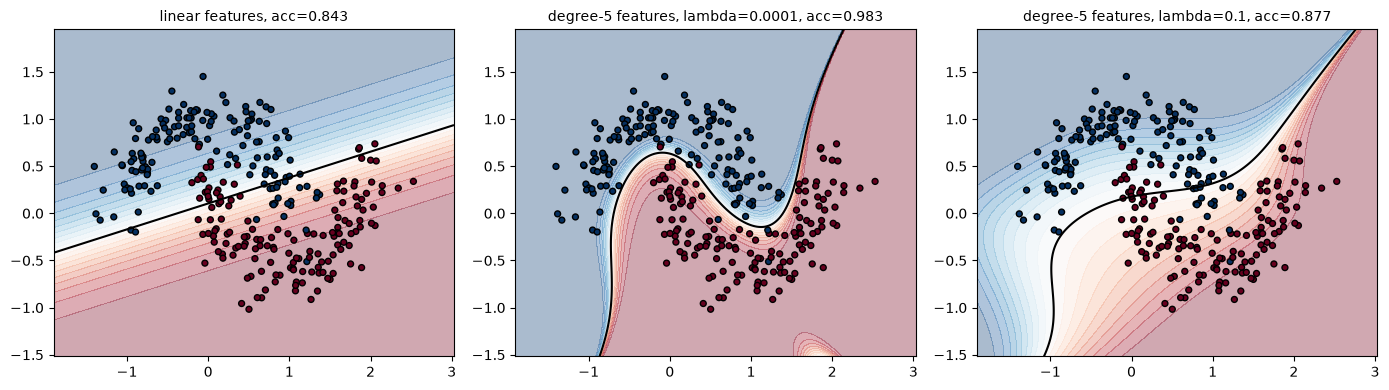

In [8]:
from sklearn.preprocessing import PolynomialFeatures

Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=0)
poly = PolynomialFeatures(degree=5, include_bias=False)
sc = StandardScaler()
Phi = sc.fit_transform(poly.fit_transform(Xm))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
lin_m = LogisticRegressionGD(lam=1e-3).fit(Xm, ym)
plot_boundary(ax[0], lin_m.predict_proba, Xm, ym, f"linear features, acc={np.mean(lin_m.predict(Xm)==ym):.3f}")
for a, lam in zip(ax[1:], [1e-4, 1e-1]):
    mdl = LogisticRegressionGD(lam=lam, n_iter=5000).fit(Phi, ym)
    f = lambda Z, mdl=mdl: mdl.predict_proba(sc.transform(poly.transform(Z)))
    plot_boundary(a, f, Xm, ym, f"degree-5 features, lambda={lam}, acc={np.mean(mdl.predict(Phi)==ym):.3f}")
plt.tight_layout(); plt.show()

## 7. Comparison with scikit-learn on breast cancer data

The Wisconsin breast cancer dataset has $n=569$ samples, $d=30$ real features, and a binary label (malignant = 0, benign = 1 in scikit-learn's coding). We **standardize** features (fit the scaler on the training set only!) — gradient descent converges much faster on well-conditioned problems, and the L2 penalty is only meaningful when features share a scale.

We pick $C = 1$ for scikit-learn and set $\lambda = 1/(nC)$ in our implementation; the two objectives are then identical, so the solutions should coincide up to optimization tolerance.

In [9]:
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target, test_size=0.3,
                                          stratify=data.target, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)
n_tr = len(y_tr)

C = 1.0
ours = LogisticRegressionGD(lam=1.0 / (n_tr * C), n_iter=50000, tol=1e-14).fit(X_tr_s, y_tr)
sk = LogisticRegression(C=C, tol=1e-10, max_iter=10000).fit(X_tr_s, y_tr)

print(f"iterations used by GD: {len(ours.history)-1}")
print(f"max |w_ours - w_sklearn| = {np.abs(ours.w - sk.coef_[0]).max():.2e}")
print(f"|b_ours - b_sklearn|     = {abs(ours.b - sk.intercept_[0]):.2e}")
print(f"test accuracy  ours: {np.mean(ours.predict(X_te_s) == y_te):.4f}   "
      f"sklearn: {sk.score(X_te_s, y_te):.4f}")
print(f"max prob diff on test set: {np.abs(ours.predict_proba(X_te_s) - sk.predict_proba(X_te_s)[:, 1]).max():.2e}")

iterations used by GD: 11808
max |w_ours - w_sklearn| = 3.39e-05
|b_ours - b_sklearn|     = 7.81e-06
test accuracy  ours: 0.9883   sklearn: 0.9883
max prob diff on test set: 5.60e-06


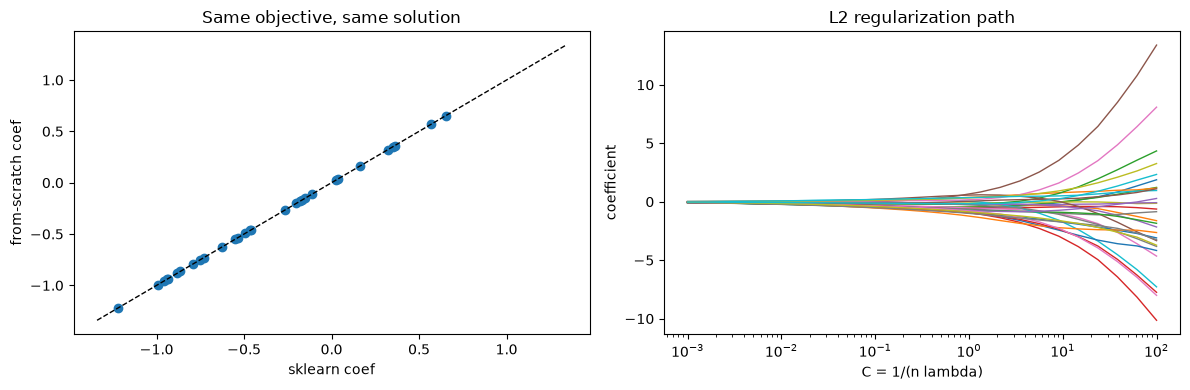

worst texture             w=-1.218  odds multiplier per +1 sd: 0.296
worst concave points      w=-0.994  odds multiplier per +1 sd: 0.370
worst area                w=-0.958  odds multiplier per +1 sd: 0.384
worst radius              w=-0.938  odds multiplier per +1 sd: 0.391
area error                w=-0.936  odds multiplier per +1 sd: 0.392


In [10]:
# Coefficient comparison and the effect of regularization strength (regularization path)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(sk.coef_[0], ours.w)
lim = np.abs(ours.w).max() * 1.1
ax[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
ax[0].set_xlabel("sklearn coef"); ax[0].set_ylabel("from-scratch coef"); ax[0].set_title("Same objective, same solution")

Cs = np.logspace(-3, 2, 25)
coefs = np.array([LogisticRegression(C=c, max_iter=5000).fit(X_tr_s, y_tr).coef_[0] for c in Cs])
ax[1].semilogx(Cs, coefs, lw=1)
ax[1].set_xlabel("C = 1/(n lambda)"); ax[1].set_ylabel("coefficient"); ax[1].set_title("L2 regularization path")
plt.tight_layout(); plt.show()
top = np.argsort(-np.abs(sk.coef_[0]))[:5]
for j in top:
    print(f"{data.feature_names[j]:<25s} w={sk.coef_[0, j]:+.3f}  odds multiplier per +1 sd: {np.exp(sk.coef_[0, j]):.3f}")

## 8. Softmax regression for multiclass problems

For $K$ classes, give each class a weight vector $\mathbf{w}_k$ (stack them as columns of $W\in\mathbb{R}^{d\times K}$) and a bias $b_k$. Scores (logits) $z_k = \mathbf{w}_k^\top\mathbf{x} + b_k$ are turned into probabilities by the **softmax**:

$$
\Pr(y = k\mid \mathbf{x}) = \mathrm{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}.
$$

For $K=2$, $\mathrm{softmax}(\mathbf{z})_1 = \sigma(z_1 - z_0)$: we recover logistic regression. Note the parametrization is **redundant** (adding the same vector to all $\mathbf{w}_k$ leaves probabilities unchanged); L2 regularization picks a unique solution.

**Loss.** With one-hot targets $Y\in\{0,1\}^{n\times K}$ and probabilities $P$, the negative log-likelihood of a categorical distribution is

$$
J(W) = -\frac1n \sum_{i=1}^n\sum_{k=1}^K Y_{ik}\log P_{ik} + \frac{\lambda}{2}\|W\|_F^2 .
$$

**Gradient derivation.** For one sample, $-\log P_{y} = -z_{y} + \log\sum_j e^{z_j}$. Differentiating w.r.t. $z_k$:

$$
\frac{\partial}{\partial z_k}\Big(-z_{y} + \log\sum_j e^{z_j}\Big) = -\mathbb{1}\{k=y\} + \frac{e^{z_k}}{\sum_j e^{z_j}} = P_k - Y_k .
$$

Chaining with $\partial z_k/\partial \mathbf{w}_k = \mathbf{x}$ gives again "prediction minus target, times input":

$$
\boxed{\nabla_W J = \frac1n X^\top (P - Y) + \lambda W,\qquad \nabla_{\mathbf{b}} J = \frac1n (P-Y)^\top\mathbf{1}.}
$$

The softmax Jacobian is $\partial P_k/\partial z_j = P_k(\delta_{kj} - P_j)$, and the loss is convex in $W$ (the log-sum-exp function is convex).

**Numerical stability.** Compute softmax as $\mathrm{softmax}(\mathbf{z} - \max_j z_j)$ — mathematically identical, but no overflow. Similarly $\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m}$ ("log-sum-exp trick").

We implement it on `load_digits` ($8\times 8$ images, $d=64$, $K=10$).

In [11]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)          # stability shift
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def log_softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    return Z - np.log(np.exp(Z).sum(axis=1, keepdims=True))

class SoftmaxRegressionGD:
    def __init__(self, lam=1e-3, lr=0.5, n_iter=1000, batch_size=None, seed=0):
        self.lam, self.lr, self.n_iter, self.batch_size, self.seed = lam, lr, n_iter, batch_size, seed

    def objective(self, X, Y):
        Z = X @ self.W + self.b
        return -np.mean(np.sum(Y * log_softmax(Z), axis=1)) + 0.5 * self.lam * np.sum(self.W ** 2)

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        Y = (y[:, None] == self.classes_[None, :]).astype(float)   # one-hot encoding, n x K
        self.W, self.b = np.zeros((d, K)), np.zeros(K)
        r = np.random.default_rng(self.seed)
        bs = self.batch_size or n
        self.history = []
        for epoch in range(self.n_iter):
            idx = r.permutation(n)
            for start in range(0, n, bs):                        # mini-batches (one batch if bs = n)
                B = idx[start:start + bs]
                P = softmax(X[B] @ self.W + self.b)
                G = P - Y[B]                                     # n_B x K  "prediction - target"
                self.W -= self.lr * (X[B].T @ G / len(B) + self.lam * self.W)
                self.b -= self.lr * G.mean(axis=0)
            self.history.append(self.objective(X, Y))
        return self

    def predict_proba(self, X):
        return softmax(X @ self.W + self.b)

    def predict(self, X):
        return self.classes_[np.argmax(X @ self.W + self.b, axis=1)]

# Gradient check of the softmax gradient on a tiny random problem
Xs, ys = rng.normal(size=(20, 3)), rng.integers(0, 4, 20)
sm = SoftmaxRegressionGD(lam=0.1); sm.W, sm.b = rng.normal(size=(3, 4)), np.zeros(4)
Ys = np.eye(4)[ys]
G_an = Xs.T @ (softmax(Xs @ sm.W) - Ys) / 20 + 0.1 * sm.W
G_num = np.zeros_like(sm.W)
for i in range(3):
    for k in range(4):
        sm.W[i, k] += 1e-6; fp = sm.objective(Xs, Ys)
        sm.W[i, k] -= 2e-6; fm = sm.objective(Xs, Ys)
        sm.W[i, k] += 1e-6
        G_num[i, k] = (fp - fm) / 2e-6
print("softmax gradient check, max abs diff:", np.abs(G_an - G_num).max())

softmax gradient check, max abs diff: 5.56597185008556e-10


from-scratch softmax test acc: 0.9741
sklearn multinomial  test acc: 0.9722
objective ours: 0.0821   sklearn solution: 0.0810


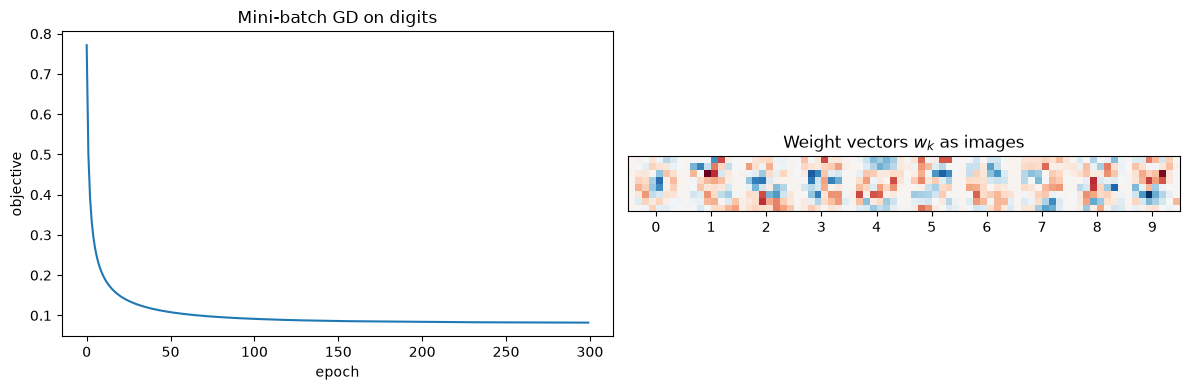

In [12]:
digits = load_digits()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.3,
                                              stratify=digits.target, random_state=0)
sc_d = StandardScaler().fit(Xd_tr)
Xd_tr_s, Xd_te_s = sc_d.transform(Xd_tr), sc_d.transform(Xd_te)

smr = SoftmaxRegressionGD(lam=1e-3, lr=0.05, n_iter=300, batch_size=32).fit(Xd_tr_s, yd_tr)
C_d = 1.0 / (len(yd_tr) * 1e-3)            # same objective in sklearn's parametrization
sk_sm = LogisticRegression(C=C_d, max_iter=5000).fit(Xd_tr_s, yd_tr)   # multinomial by default

print(f"from-scratch softmax test acc: {np.mean(smr.predict(Xd_te_s) == yd_te):.4f}")
print(f"sklearn multinomial  test acc: {sk_sm.score(Xd_te_s, yd_te):.4f}")
print(f"objective ours: {smr.history[-1]:.4f}   sklearn solution: "
      f"{(lambda m: -np.mean(np.log(m.predict_proba(Xd_tr_s)[np.arange(len(yd_tr)), yd_tr])) + 0.5e-3*np.sum(m.coef_**2))(sk_sm):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(smr.history); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("objective"); ax[0].set_title("Mini-batch GD on digits")
# Visualize the learned class templates (weight vectors mapped back to 8x8 images)
tiles = np.concatenate([smr.W[:, k].reshape(8, 8) for k in range(10)], axis=1)
ax[1].imshow(tiles, cmap="RdBu_r"); ax[1].set_yticks([])
ax[1].set_xticks(np.arange(10) * 8 + 3.5); ax[1].set_xticklabels(range(10)); ax[1].set_title("Weight vectors $w_k$ as images")
plt.tight_layout(); plt.show()

**One-vs-rest (OvR) vs multinomial.** An alternative is to train $K$ independent binary classifiers ("class $k$ vs rest") and predict the argmax score. OvR's probabilities do not sum to one and each classifier sees an imbalanced problem, while softmax regression trains one coherent probabilistic model. In practice accuracies are often similar, but softmax probabilities are better calibrated.

## 9. Classification metrics

For a binary classifier with positive class $1$, the **confusion matrix** counts

| | predicted $+$ | predicted $-$ |
|---|---|---|
| **actual $+$** | TP | FN |
| **actual $-$** | FP | TN |

From it:

- **Accuracy** $= \frac{TP+TN}{TP+TN+FP+FN}$ — misleading under class imbalance.
- **Precision** (positive predictive value) $= \frac{TP}{TP+FP}$: "of what I flagged, how much is right?"
- **Recall** (sensitivity, true positive rate, TPR) $= \frac{TP}{TP+FN}$: "of all positives, how many did I find?"
- **Specificity** $= \frac{TN}{TN+FP} = 1 - \text{FPR}$.
- **$F_1$** $= \frac{2\,\text{P}\cdot\text{R}}{\text{P}+\text{R}} = \frac{2TP}{2TP+FP+FN}$, the harmonic mean; more generally $F_\beta = (1+\beta^2)\frac{PR}{\beta^2 P + R}$ weights recall $\beta$ times as much as precision.

For multiclass problems, per-class metrics are averaged: **macro** (unweighted mean over classes), **weighted** (by support), or **micro** (pool all TP/FP/FN; micro-$F_1$ equals accuracy for single-label problems).

In the breast cancer data the *clinically relevant* positive class is **malignant** (label 0 in sklearn). We relabel so that $1 =$ malignant.

TP=63 FP=1 FN=1 TN=106
from scratch: acc=0.9883 precision=0.9844 recall=0.9844 F1=0.9844
sklearn:      acc=0.9883 precision=0.9844 recall=0.9844 F1=0.9844


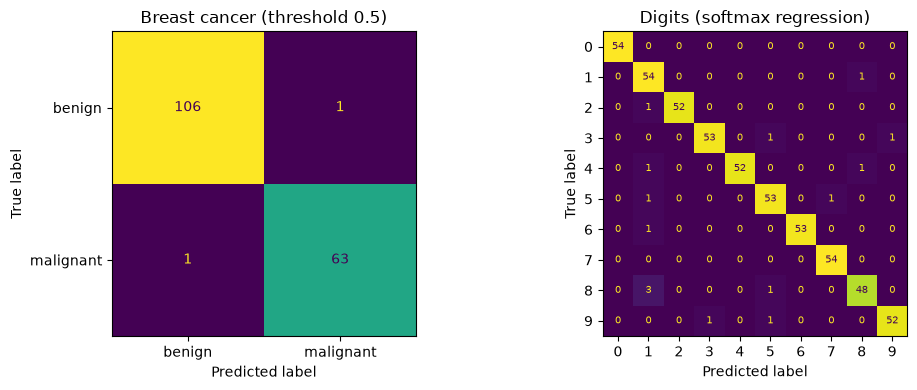

 0.981     0.963     0.972        54

    accuracy                          0.972       540
   macro avg      0.974     0.972     0.972       540
weighted avg      0.973     0.972     0.972       540



In [13]:
# Positive class = malignant
yt = 1 - y_te
clf_bc = LogisticRegression(C=1.0, max_iter=5000).fit(X_tr_s, 1 - y_tr)
scores = clf_bc.predict_proba(X_te_s)[:, 1]        # P(malignant | x)
yhat = (scores >= 0.5).astype(int)

def confusion(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1)); fn = np.sum((y_true == 1) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1)); tn = np.sum((y_true == 0) & (y_pred == 0))
    return tp, fp, fn, tn

tp, fp, fn, tn = confusion(yt, yhat)
acc = (tp + tn) / len(yt); prec = tp / (tp + fp); rec = tp / (tp + fn); f1 = 2 * prec * rec / (prec + rec)
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"from scratch: acc={acc:.4f} precision={prec:.4f} recall={rec:.4f} F1={f1:.4f}")
print(f"sklearn:      acc={metrics.accuracy_score(yt, yhat):.4f} precision={metrics.precision_score(yt, yhat):.4f} "
      f"recall={metrics.recall_score(yt, yhat):.4f} F1={metrics.f1_score(yt, yhat):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
metrics.ConfusionMatrixDisplay.from_predictions(yt, yhat, display_labels=["benign", "malignant"], ax=ax[0], colorbar=False)
ax[0].set_title("Breast cancer (threshold 0.5)")
yd_pred = sk_sm.predict(Xd_te_s)
metrics.ConfusionMatrixDisplay.from_predictions(yd_te, yd_pred, ax=ax[1], colorbar=False, text_kw={"fontsize": 7})
ax[1].set_title("Digits (softmax regression)")
plt.tight_layout(); plt.show()
print(metrics.classification_report(yd_te, yd_pred, digits=3)[-200:])

## 10. ROC curves and AUC (from scratch)

A probabilistic classifier produces a **score** $s(\mathbf{x})$; each threshold $t$ yields a classifier $\mathbb{1}\{s(\mathbf{x})\ge t\}$. The **ROC curve** traces $(\text{FPR}(t), \text{TPR}(t))$ as $t$ sweeps from $+\infty$ (nothing predicted positive, point $(0,0)$) to $-\infty$ (everything positive, point $(1,1)$).

**Algorithm** ($O(n\log n)$): sort samples by decreasing score; walk down the list, and at each *distinct* score value record cumulative TP and FP counts divided by $n_+$ and $n_-$. Ties must be grouped, otherwise the curve depends on arbitrary ordering.

**AUC** is the area under the ROC curve (trapezoidal rule). It has a beautiful probabilistic meaning:

$$
\text{AUC} = \Pr\big(s(\mathbf{x}^+) > s(\mathbf{x}^-)\big) + \tfrac12\Pr\big(s(\mathbf{x}^+) = s(\mathbf{x}^-)\big),
$$

the probability that a random positive is ranked above a random negative — the normalized **Mann–Whitney $U$** statistic. AUC $=0.5$ is random ranking, $1$ is perfect ranking. AUC is **threshold-free** and **invariant to monotone transformations** of the score: it measures ranking quality, *not* calibration.

In [14]:
def roc_curve_scratch(y_true, score):
    order = np.argsort(-score, kind="mergesort")
    s, y = score[order], y_true[order]
    # indices where the score changes -> one ROC point per distinct threshold
    distinct = np.r_[np.where(np.diff(s))[0], len(s) - 1]
    tps = np.cumsum(y)[distinct]
    fps = (distinct + 1) - tps
    tpr = np.r_[0, tps / y.sum()]
    fpr = np.r_[0, fps / (len(y) - y.sum())]
    thresholds = np.r_[np.inf, s[distinct]]
    return fpr, tpr, thresholds

def auc_trapezoid(x, y):
    return np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2)

def auc_pairwise(y_true, score):
    # Mann-Whitney: fraction of (positive, negative) pairs ranked correctly, ties count 1/2
    pos, neg = score[y_true == 1], score[y_true == 0]
    diff = pos[:, None] - neg[None, :]
    return np.mean(diff > 0) + 0.5 * np.mean(diff == 0)

fpr, tpr, thr = roc_curve_scratch(yt, scores)
fpr_sk, tpr_sk, _ = metrics.roc_curve(yt, scores, drop_intermediate=False)
print(f"AUC trapezoid (scratch): {auc_trapezoid(fpr, tpr):.6f}")
print(f"AUC pairwise  (scratch): {auc_pairwise(yt, scores):.6f}")
print(f"AUC sklearn:             {metrics.roc_auc_score(yt, scores):.6f}")
print("curves identical:", np.allclose(fpr, fpr_sk) and np.allclose(tpr, tpr_sk))

AUC trapezoid (scratch): 0.998102
AUC pairwise  (scratch): 0.998102
AUC sklearn:             0.998102
curves identical: True


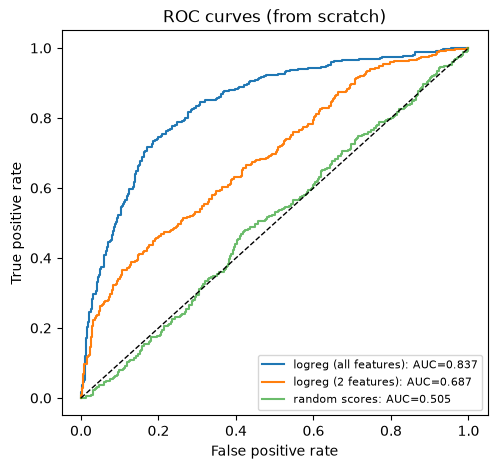

In [15]:
# ROC curves for several models of different quality on a harder synthetic problem
Xh, yh = make_classification(n_samples=2000, n_features=20, n_informative=4, flip_y=0.1,
                             weights=[0.7, 0.3], random_state=1)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=0.5, stratify=yh, random_state=0)
models = {
    "logreg (all features)": (LogisticRegression(max_iter=2000), slice(None)),
    "logreg (2 features)": (LogisticRegression(max_iter=2000), slice(0, 2)),
}
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, (mdl, cols) in models.items():
    sc_h = mdl.fit(Xh_tr[:, cols], yh_tr).predict_proba(Xh_te[:, cols])[:, 1]
    f_, t_, _ = roc_curve_scratch(yh_te, sc_h)
    ax.plot(f_, t_, label=f"{name}: AUC={auc_trapezoid(f_, t_):.3f}")
rand = rng.random(len(yh_te))
f_, t_, _ = roc_curve_scratch(yh_te, rand)
ax.plot(f_, t_, label=f"random scores: AUC={auc_trapezoid(f_, t_):.3f}", alpha=0.7)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.set_title("ROC curves (from scratch)")
ax.legend(loc="lower right", fontsize=8); plt.show()

## 11. Precision–recall curves and threshold selection

The **precision–recall (PR) curve** plots precision vs recall across thresholds. Unlike ROC, it depends on the class prior: a random classifier has precision $\pi = n_+/n$ (a horizontal line), not a diagonal. When positives are **rare**, ROC can look deceptively good because FPR divides by the huge $n_-$; PR curves expose the false-positive burden. The area is summarized by **average precision** $\text{AP} = \sum_k (R_k - R_{k-1})P_k$.

**Choosing a threshold.** $0.5$ is optimal only for equal misclassification costs and calibrated probabilities. With cost $c_{FN}$ for a false negative and $c_{FP}$ for a false positive, Bayes decision theory says predict positive iff

$$
c_{FN}\,p(\mathbf{x}) > c_{FP}\,(1-p(\mathbf{x})) \iff p(\mathbf{x}) > t^* = \frac{c_{FP}}{c_{FP}+c_{FN}} .
$$

Other strategies: maximize $F_1$ / $F_\beta$, maximize Youden's $J = \text{TPR} - \text{FPR}$, or fix a required recall (e.g. "find 98% of cancers") and take the largest threshold achieving it. **Always pick the threshold on validation data**, never on the test set; here we use the test set only to illustrate.

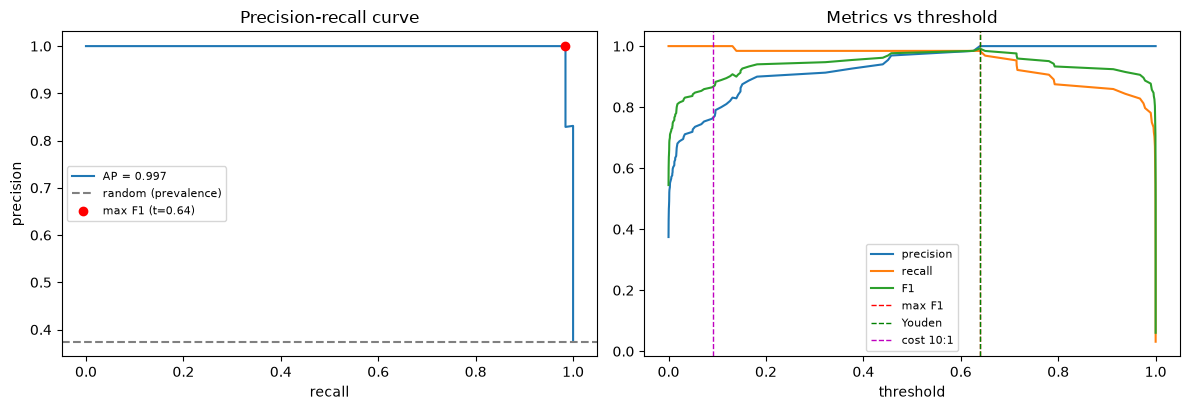

           0.5: t=0.500  TP= 63 FP=  1 FN=  1 TN=106  precision=0.984 recall=0.984
        max F1: t=0.639  TP= 63 FP=  0 FN=  1 TN=107  precision=1.000 recall=0.984
        Youden: t=0.639  TP= 63 FP=  0 FN=  1 TN=107  precision=1.000 recall=0.984
 cost FN=10xFP: t=0.091  TP= 64 FP= 19 FN=  0 TN= 88  precision=0.771 recall=1.000
  recall>=0.98: t=0.639  TP= 63 FP=  0 FN=  1 TN=107  precision=1.000 recall=0.984


In [16]:
prec_c, rec_c, thr_pr = metrics.precision_recall_curve(yt, scores)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / np.clip(prec_c[:-1] + rec_c[:-1], 1e-12, None)
best_f1 = np.argmax(f1_c)
youden = np.argmax(tpr - fpr)
cost_t = 1 / (1 + 10)                        # c_FP = 1, c_FN = 10  ->  t* = 1/11
idx_rec = np.where(rec_c[:-1] >= 0.98)[0][-1]   # largest threshold with recall >= 0.98

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(rec_c, prec_c, label=f"AP = {metrics.average_precision_score(yt, scores):.3f}")
ax[0].axhline(yt.mean(), ls="--", c="gray", label="random (prevalence)")
ax[0].scatter(rec_c[best_f1], prec_c[best_f1], c="r", zorder=3, label=f"max F1 (t={thr_pr[best_f1]:.2f})")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].legend(fontsize=8); ax[0].set_title("Precision-recall curve")

ax[1].plot(thr_pr, prec_c[:-1], label="precision"); ax[1].plot(thr_pr, rec_c[:-1], label="recall")
ax[1].plot(thr_pr, f1_c, label="F1")
for t, lab, c in [(thr_pr[best_f1], "max F1", "r"), (thr[youden], "Youden", "g"), (cost_t, "cost 10:1", "m")]:
    ax[1].axvline(t, ls="--", c=c, lw=1, label=lab)
ax[1].set_xlabel("threshold"); ax[1].legend(fontsize=8); ax[1].set_title("Metrics vs threshold")
plt.tight_layout(); plt.show()

for name, t in [("0.5", 0.5), ("max F1", thr_pr[best_f1]), ("Youden", thr[youden]),
                ("cost FN=10xFP", cost_t), ("recall>=0.98", thr_pr[idx_rec])]:
    tp, fp, fn, tn = confusion(yt, (scores >= t).astype(int))
    print(f"{name:>14s}: t={t:.3f}  TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}  "
          f"precision={tp/(tp+fp):.3f} recall={tp/(tp+fn):.3f}")

## 12. Class imbalance

With prevalence $\pi \ll 0.5$, a classifier that always predicts the majority class has accuracy $1-\pi$ yet is useless. Remedies:

1. **Use appropriate metrics**: PR-AUC / AP, recall at fixed precision, balanced accuracy $\frac12(\text{TPR}+\text{TNR})$, macro-$F_1$, Matthews correlation.
2. **Move the threshold** (Section 11). Logistic regression trained on imbalanced data is still (approximately) calibrated — the posterior just rarely exceeds $0.5$.
3. **Reweight the loss**: `class_weight="balanced"` multiplies each sample's loss by $n/(K n_{c})$. For logistic regression this mainly shifts the intercept by roughly $\log\frac{1-\pi}{\pi}$ — similar in effect to lowering the threshold — but it **destroys calibration**.
4. **Resample**: undersample the majority / oversample the minority (e.g. SMOTE). Same calibration caveat; must be done *inside* cross-validation folds (Lecture 04).

In [17]:
Xi, yi = make_classification(n_samples=6000, n_features=10, n_informative=4, weights=[0.97, 0.03],
                             flip_y=0.01, class_sep=0.8, random_state=7)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.5, stratify=yi, random_state=0)
print(f"positive rate: {yi_tr.mean():.3f}   majority-class baseline accuracy: {1 - yi_te.mean():.3f}")

plain = LogisticRegression(max_iter=2000).fit(Xi_tr, yi_tr)
balanced = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xi_tr, yi_tr)
p_plain, p_bal = plain.predict_proba(Xi_te)[:, 1], balanced.predict_proba(Xi_te)[:, 1]
print(f"intercepts: plain={plain.intercept_[0]:.3f} balanced={balanced.intercept_[0]:.3f} "
      f"(shift {balanced.intercept_[0]-plain.intercept_[0]:.2f}; log((1-pi)/pi) = {np.log((1-yi_tr.mean())/yi_tr.mean()):.2f})")

rows = [("plain, t=0.5", p_plain, 0.5), ("plain, t=prevalence", p_plain, yi_tr.mean()), ("balanced, t=0.5", p_bal, 0.5)]
for name, p_, t in rows:
    yp = (p_ >= t).astype(int)
    print(f"{name:>22s}: acc={metrics.accuracy_score(yi_te, yp):.3f} bal_acc={metrics.balanced_accuracy_score(yi_te, yp):.3f} "
          f"prec={metrics.precision_score(yi_te, yp, zero_division=0):.3f} rec={metrics.recall_score(yi_te, yp):.3f} "
          f"F1={metrics.f1_score(yi_te, yp):.3f}")
print(f"ranking quality (threshold-free): ROC-AUC plain={metrics.roc_auc_score(yi_te, p_plain):.3f} "
      f"balanced={metrics.roc_auc_score(yi_te, p_bal):.3f};  AP plain={metrics.average_precision_score(yi_te, p_plain):.3f}")

positive rate: 0.034   majority-class baseline accuracy: 0.966
intercepts: plain=-2.473 balanced=0.523 (shift 3.00; log((1-pi)/pi) = 3.35)
          plain, t=0.5: acc=0.969 bal_acc=0.577 prec=0.696 rec=0.157 F1=0.256
   plain, t=prevalence: acc=0.819 bal_acc=0.746 prec=0.118 rec=0.667 F1=0.201
       balanced, t=0.5: acc=0.830 bal_acc=0.784 prec=0.135 rec=0.735 F1=0.228
ranking quality (threshold-free): ROC-AUC plain=0.822 balanced=0.851;  AP plain=0.369


## 13. Probability calibration

A classifier is **calibrated** if, among all inputs where it predicts probability $q$, a fraction $q$ is actually positive: $\Pr(y=1\mid \hat p(\mathbf{x}) = q) = q$. Calibration matters whenever probabilities are *used* (expected-cost decisions, risk communication, combining models).

A **reliability diagram (calibration curve)** bins the predicted probabilities and plots the observed positive frequency per bin against the mean prediction; a calibrated model lies on the diagonal. Scalar summaries:

- **Brier score** $\frac1n\sum_i (\hat p_i - y_i)^2$ (a proper scoring rule; decomposes into calibration + refinement terms).
- **Log loss** (cross-entropy), also proper.
- **Expected calibration error** $\text{ECE} = \sum_b \frac{n_b}{n}\,|\bar y_b - \bar p_b|$.

Logistic regression minimizes a proper scoring rule, so a well-specified, not-overregularized model tends to be well calibrated. Class reweighting, strong regularization, and models like naive Bayes, SVMs or boosted trees are often miscalibrated. Fixes: **Platt scaling** (fit a 1-D logistic regression on the scores) or **isotonic regression**, trained on held-out data (`CalibratedClassifierCV`).

           logistic regression: Brier=0.1309 logloss=0.4264 ECE=0.0311 AUC=0.7558
 logreg, class_weight=balanced: Brier=0.1994 logloss=0.5837 ECE=0.2416 AUC=0.7572
          Gaussian naive Bayes: Brier=0.1630 logloss=0.5614 ECE=0.1270 AUC=0.6978
  GaussianNB + isotonic calib.: Brier=0.1360 logloss=0.4388 ECE=0.0133 AUC=0.6975


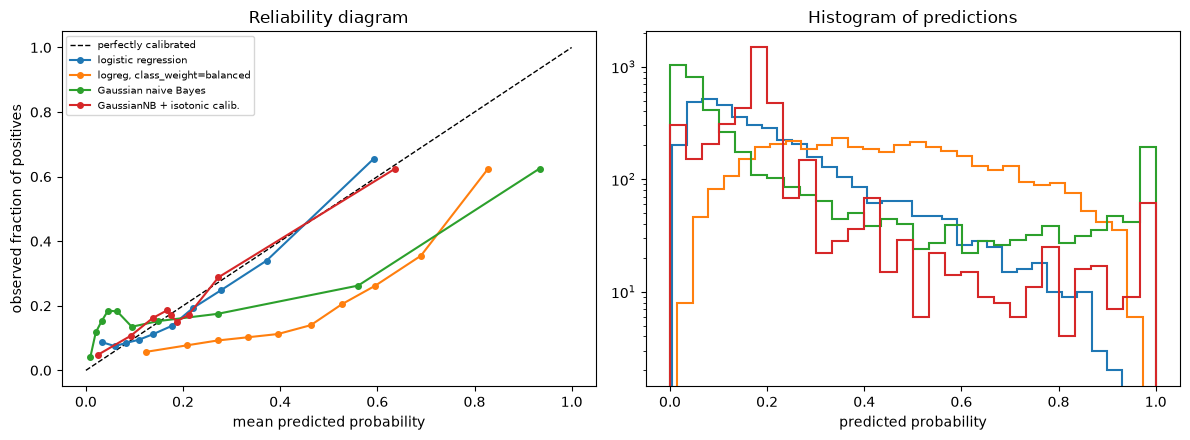

In [18]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB

def ece(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    return sum(np.mean(bins == b) * abs(y[bins == b].mean() - p[bins == b].mean())
               for b in range(n_bins) if np.any(bins == b))

Xc_, yc_ = make_classification(n_samples=8000, n_features=20, n_informative=4, n_redundant=0,
                               weights=[0.8, 0.2], random_state=0)
# Append two noisy copies of the informative features: this violates naive Bayes' conditional
# independence assumption (evidence gets "double counted"), making NB over-confident.
noise = np.random.default_rng(0).normal(scale=0.3, size=(len(yc_), 8))
Xc_ = np.c_[Xc_, np.tile(Xc_[:, :4], 2) + noise]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc_, yc_, test_size=0.5, stratify=yc_, random_state=0)
cands = {
    "logistic regression": LogisticRegression(max_iter=2000),
    "logreg, class_weight=balanced": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Gaussian naive Bayes": GaussianNB(),
    "GaussianNB + isotonic calib.": CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5),
}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
for name, mdl in cands.items():
    p_ = mdl.fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]
    frac_pos, mean_pred = calibration_curve(yc_te, p_, n_bins=10, strategy="quantile")
    ax[0].plot(mean_pred, frac_pos, "o-", ms=4, label=name)
    ax[1].hist(p_, bins=30, histtype="step", lw=1.5, label=name)
    print(f"{name:>30s}: Brier={metrics.brier_score_loss(yc_te, p_):.4f} "
          f"logloss={metrics.log_loss(yc_te, p_):.4f} ECE={ece(yc_te, p_):.4f} AUC={metrics.roc_auc_score(yc_te, p_):.4f}")
ax[0].set_xlabel("mean predicted probability"); ax[0].set_ylabel("observed fraction of positives")
ax[0].set_title("Reliability diagram"); ax[0].legend(fontsize=7)
ax[1].set_yscale("log"); ax[1].set_xlabel("predicted probability"); ax[1].set_title("Histogram of predictions")
plt.tight_layout(); plt.show()

Observe that class reweighting and naive Bayes (whose independence assumption is violated by the duplicated features) are poorly calibrated (high Brier/ECE) even though their ranking (AUC) is reasonable; isotonic calibration repairs the probabilities without hurting the ranking much.

## 14. Pitfalls & practical tips

- **Scale your features.** GD step sizes and the L2 penalty both assume comparable feature scales. Fit the scaler on the training data only.
- **Separable data** makes the unregularized MLE diverge; always keep some regularization (sklearn's default $C=1$ is already L2-regularized — remember this when interpreting coefficients as "the MLE").
- **Coefficients are conditional effects** on the log-odds scale; with correlated features they can flip sign and are not measures of importance without care.
- **Use stable primitives**: `np.logaddexp`, log-softmax, and clipped probabilities in log loss.
- **Accuracy is not enough**: report a confusion matrix and metrics that match the application's costs; with imbalance prefer PR curves / AP.
- **ROC-AUC measures ranking, not calibration.** A model can have AUC 0.95 and terrible probabilities.
- **Tune the threshold on validation data**, and when using `class_weight` or resampling, do not interpret the outputs as calibrated probabilities.
- **Multiclass**: prefer softmax (multinomial) over OvR when you need probabilities; report macro-averaged metrics if all classes matter equally.

## 15. Exercises

**Exercise 1 (math).** Show that $\sigma'(z) = \sigma(z)(1-\sigma(z))$ and that for $K=2$ softmax regression with weights $\mathbf{w}_0, \mathbf{w}_1$ is equivalent to logistic regression with $\mathbf{w} = \mathbf{w}_1 - \mathbf{w}_0$.

**Exercise 2 (math).** Prove that if the training data are linearly separable, the unregularized logistic loss has no minimizer (the infimum $0$ is not attained). What happens to $\|\mathbf{w}\|$ along gradient descent iterates? (Hint: consider $c\,\mathbf{w}_{\text{sep}}$ for $c\to\infty$.)

**Exercise 3 (coding).** Implement Newton's method (IRLS) for L2-regularized logistic regression using the Hessian $\frac1n X^\top S X + \lambda I$ (do not penalize the bias). Compare the number of iterations needed to reach the scikit-learn solution on the breast cancer data with gradient descent.

**Exercise 4 (coding).** Implement the precision–recall curve and average precision from scratch (analogous to `roc_curve_scratch`) and verify against `metrics.precision_recall_curve` / `average_precision_score`.

**Exercise 5 (coding + analysis).** Implement Platt scaling: given held-out scores $s_i$, fit $\hat p = \sigma(a s_i + c)$ by minimizing log loss (you may reuse `LogisticRegressionGD`). Apply it to the Gaussian naive Bayes log-odds from Section 13 and compare the reliability diagram and ECE with isotonic calibration.

**Exercise 6 (math).** Show that AUC equals the normalized Mann–Whitney statistic, i.e. that the trapezoidal area under the empirical ROC curve equals $\Pr(s^+ > s^-) + \frac12\Pr(s^+ = s^-)$ over the empirical pairs.

In [19]:
# Exercise 3 starter: Newton / IRLS for L2-regularized logistic regression
def fit_logreg_newton(X, y, lam=0.0, n_iter=20):
    # TODO: augment X with a column of ones, build the Hessian (1/n) X^T S X + lam * I
    #       (with a 0 on the diagonal entry of the bias), and iterate
    #       w <- w - H^{-1} grad.  Return (w, b, list_of_objective_values).
    return None

# Exercise 4 starter: precision-recall curve from scratch
def pr_curve_scratch(y_true, score):
    # TODO: sort by decreasing score, group ties, compute cumulative TP and FP,
    #       precision = TP / (TP + FP), recall = TP / n_pos. Return (precision, recall, thresholds).
    return None

# Exercise 5 starter: Platt scaling
def platt_scale(scores_val, y_val):
    # TODO: fit a 1-D logistic regression p = sigmoid(a * s + c) on validation scores;
    #       return a function mapping new scores to calibrated probabilities.
    return None

print("Starter stubs defined:", fit_logreg_newton, pr_curve_scratch, platt_scale, sep="\n  ")

Starter stubs defined:
  <function fit_logreg_newton at 0x7fabcf5ca8e0>
  <function pr_curve_scratch at 0x7fabcf5cb600>
  <function platt_scale at 0x7fabcf5cb7e0>


## 16. Summary

- Logistic regression models the log-odds as linear: $\Pr(y=1\mid\mathbf{x}) = \sigma(\mathbf{w}^\top\mathbf{x}+b)$; its decision boundary is a hyperplane.
- Maximum likelihood under a Bernoulli model gives the **cross-entropy loss**; its gradient is $\frac1n X^\top(\mathbf{p}-\mathbf{y})$ and its Hessian $\frac1n X^\top S X \succeq 0$, so the problem is **convex**.
- L2 regularization makes the problem strongly convex, prevents divergence on separable data, and corresponds to sklearn's `C` via $\lambda = 1/(nC)$.
- **Softmax regression** generalizes to $K$ classes with the same "prediction minus target" gradient $\frac1n X^\top(P-Y)$.
- Evaluate with confusion matrices and application-appropriate metrics; **ROC-AUC** measures ranking (= Mann–Whitney probability), **PR curves** are more informative under imbalance.
- The decision **threshold** is a separate design choice driven by costs; choose it on validation data.
- **Calibration** is distinct from discrimination; check it with reliability diagrams, Brier score and ECE, and repair it with Platt or isotonic scaling.

## Further reading

- James, Witten, Hastie, Tibshirani, Taylor — *ISLP*, Ch. 4 (Classification).
- Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning*, §4.4 (Logistic regression).
- Bishop — *Pattern Recognition and Machine Learning*, §4.2–4.3 (probabilistic generative/discriminative models, IRLS).
- Murphy — *Probabilistic Machine Learning: An Introduction*, Ch. 10 (Logistic regression) and §5.1 (decision theory).
- Géron — *Hands-On Machine Learning*, Ch. 3 (Classification) and Ch. 4 (Logistic & softmax regression).
- Fawcett (2006), "An introduction to ROC analysis", *Pattern Recognition Letters*.
- Niculescu-Mizil & Caruana (2005), "Predicting good probabilities with supervised learning", *ICML*.
- Platt (1999), "Probabilistic outputs for support vector machines"; Guo et al. (2017), "On calibration of modern neural networks", *ICML*.